# SurveyCTO GeoJSON Test

Generate 200m grid cells around office locations and export as GeoJSON for SurveyCTO testing.

In [ ]:
import geopandas as gpd
import json
from shapely.geometry import Polygon, mapping
from pathlib import Path

In [2]:
# Office locations (lat, lon)
offices = {
    "dar_es_salaam": (-6.778436239590647, 39.25134881249597),
    "kampala": (0.3421994896849769, 32.59192784637421), 
    "amsterdam": (52.37297325089347, 4.887482952303158)  # <-- add coordinates here
}

GRID_SIZE = 200  # metres
OUTPUT_DIR = Path(r"G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\surveycto_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
for name, (lat, lon) in offices.items():
    # Create point in WGS84, project to UTM for metric buffer
    point = gpd.GeoSeries.from_xy([lon], [lat], crs="EPSG:4326")
    utm_crs = point.estimate_utm_crs()
    point_utm = point.to_crs(utm_crs)

    cx, cy = point_utm.iloc[0].x, point_utm.iloc[0].y
    half = GRID_SIZE / 2

    # Chevron: square with left edge pushed to a center point
    #
    #   (cx-half, cy+half) ---- (cx+half, cy+half)
    #        \                        |
    #         (cx, cy)                |
    #        /                        |
    #   (cx-half, cy-half) ---- (cx+half, cy-half)
    #
    chevron = Polygon([
        (cx, cy),                    # left point
        (cx - half, cy + half),      # top-left
        (cx + half, cy + half),      # top-right
        (cx + half, cy - half),      # bottom-right
        (cx - half, cy - half),      # bottom-left
    ])

    # Convert back to WGS84
    gdf = gpd.GeoDataFrame({"name": [name]}, geometry=[chevron], crs=utm_crs)
    gdf_wgs84 = gdf.to_crs(epsg=4326)

    # Compute centroid in WGS84
    centroid = gdf_wgs84.geometry.iloc[0].centroid

    # Export as GeoJSON
    geojson = {
        "type": "FeatureCollection",
        "features": [{
            "type": "Feature",
            "properties": {
                "name": name,
                "grid_size_m": GRID_SIZE,
                "centroid_lat": centroid.y,
                "centroid_lon": centroid.x,
            },
            "geometry": mapping(gdf_wgs84.geometry.iloc[0]),
        }],
    }

    out_path = OUTPUT_DIR / f"{name}_{GRID_SIZE}m.geojson"
    out_path.write_text(json.dumps(geojson, indent=2))
    print(f"{name}: saved to {out_path}")
    print(f"  Centroid: {centroid.y:.6f}, {centroid.x:.6f}")
    print(f"  Bounds: {gdf_wgs84.total_bounds}")
    print(f"  UTM CRS: {utm_crs}")
    print()

Saved map: G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\surveycto_test\dar_es_salaam_200m_map.png


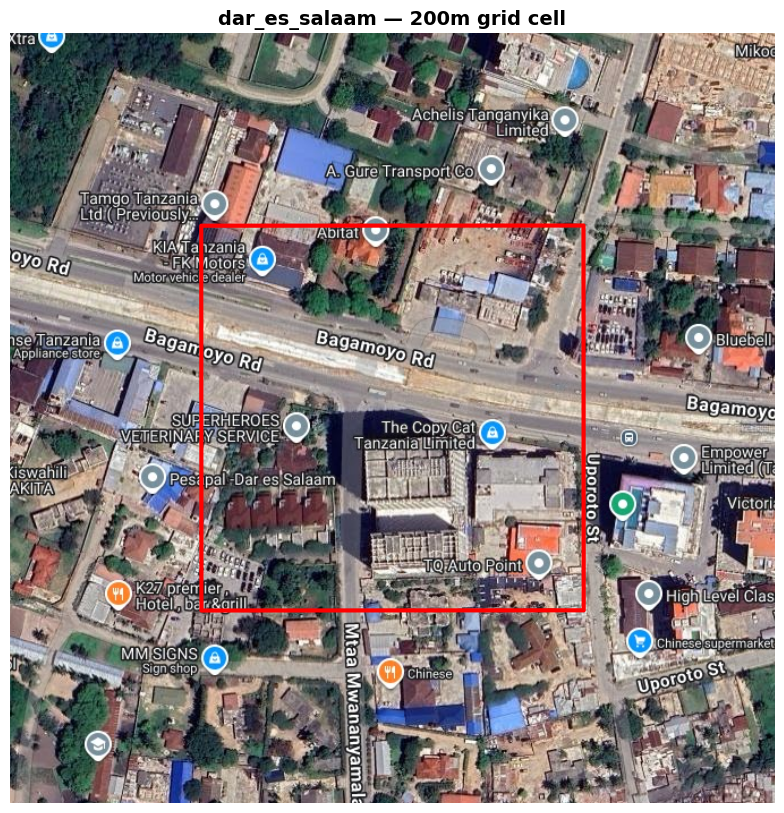

Saved map: G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\surveycto_test\kampala_200m_map.png


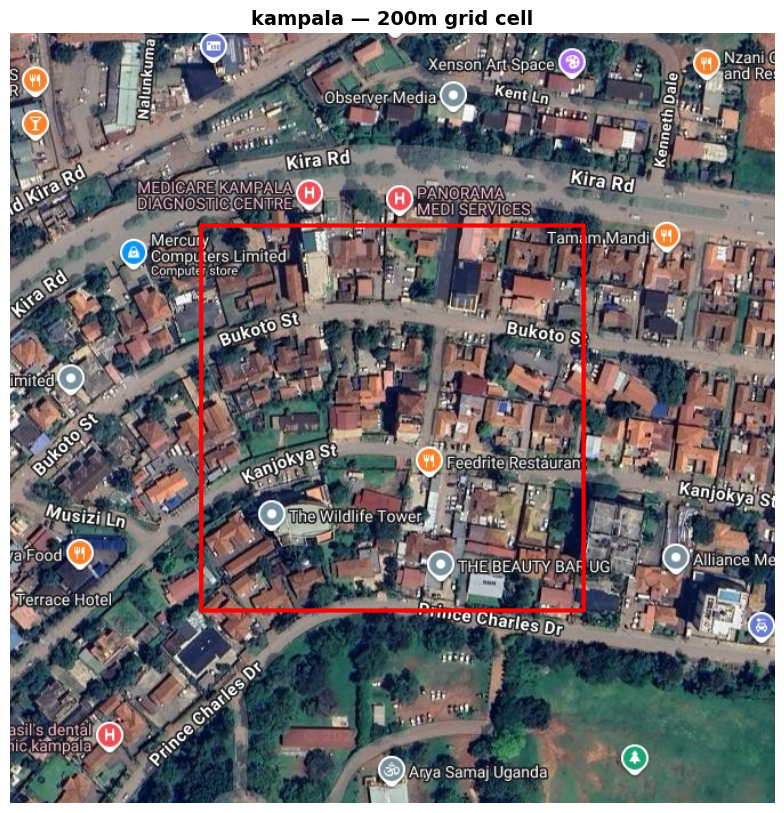

Saved map: G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\surveycto_test\amsterdam_200m_map.png


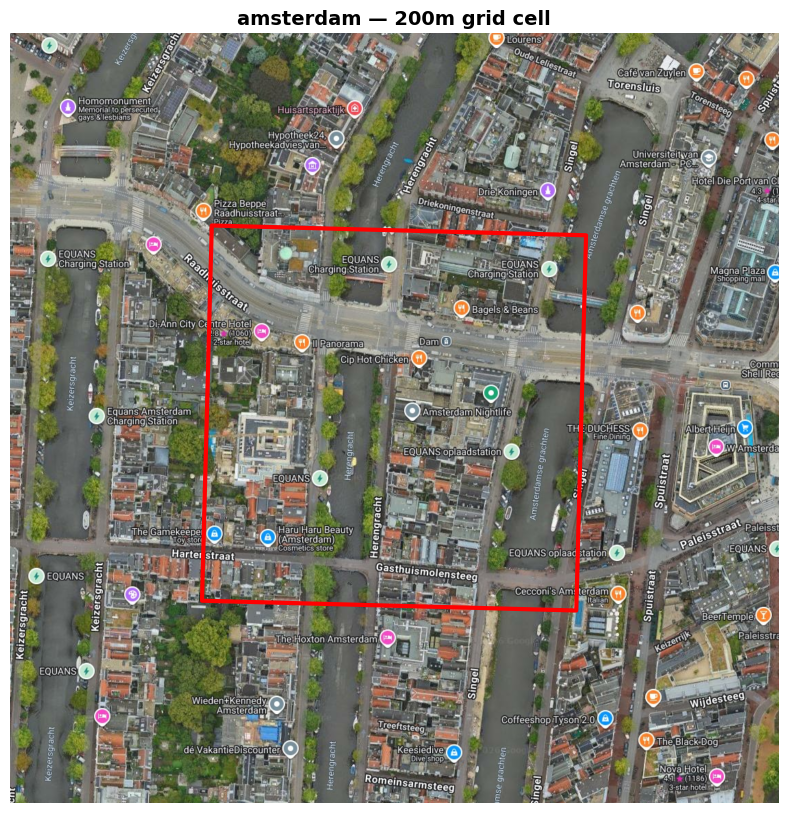

In [4]:
# Generate a static map with the grid overlaid on satellite imagery
import contextily as cx
import matplotlib.pyplot as plt

for name, (lat, lon) in offices.items():
    geojson_path = OUTPUT_DIR / f"{name}_{GRID_SIZE}m.geojson"
    gdf = gpd.read_file(geojson_path)
    gdf_wm = gdf.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_wm.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=3)

    # Buffer view
    bounds = gdf_wm.total_bounds
    dx = (bounds[2] - bounds[0]) * 0.5
    dy = (bounds[3] - bounds[1]) * 0.5
    ax.set_xlim(bounds[0] - dx, bounds[2] + dx)
    ax.set_ylim(bounds[1] - dy, bounds[3] + dy)

    cx.add_basemap(ax, source="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}", zoom=18)

    ax.set_title(f"{name} â€” {GRID_SIZE}m grid cell", fontsize=14, fontweight="bold")
    ax.set_axis_off()

    map_path = OUTPUT_DIR / f"{name}_{GRID_SIZE}m_map.png"
    fig.savefig(map_path, dpi=150, bbox_inches="tight")
    print(f"Saved map: {map_path}")
    plt.show()


In [5]:
# Interactive Folium map (saved as HTML)
import folium

for name, (lat, lon) in offices.items():
    geojson_path = OUTPUT_DIR / f"{name}_{GRID_SIZE}m.geojson"
    geojson_data = json.loads(geojson_path.read_text())

    m = folium.Map(location=[lat, lon], zoom_start=17, tiles="OpenStreetMap")
    folium.TileLayer(
        tiles="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}",
        attr="Google Hybrid", name="Google Hybrid"
    ).add_to(m)
    folium.GeoJson(geojson_data, style_function=lambda x: {
        "color": "red", "weight": 3, "fillOpacity": 0.2
    }).add_to(m)
    folium.Marker([lat, lon], popup=name).add_to(m)
    folium.LayerControl().add_to(m)

    # Save as HTML
    html_path = OUTPUT_DIR / f"{name}_{GRID_SIZE}m_map.html"
    m.save(str(html_path))
    print(f"Saved interactive map: {html_path}")
    display(m)


Saved interactive map: G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\surveycto_test\dar_es_salaam_200m_map.html


Saved interactive map: G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\surveycto_test\kampala_200m_map.html


Saved interactive map: G:\Shared drives\TZ-CCT_RUBEV-0825\Data\0_Listing\1_Input\surveycto_test\amsterdam_200m_map.html
